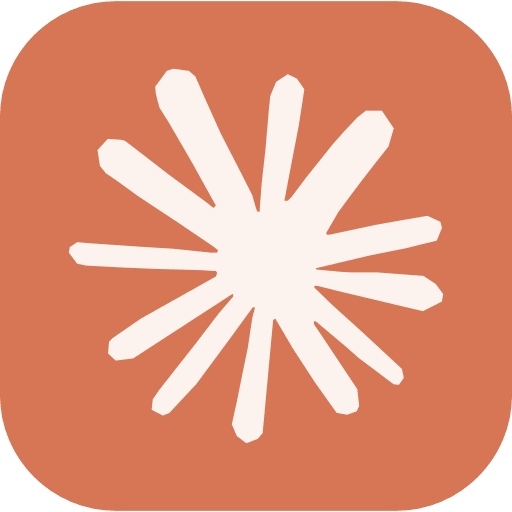

# Chapter 12 — Ethical Reasoning Agent

**Book:** *30 Agents Every AI Engineer Must Build*
**Author:** Imran Ahmad | **Publisher:** Packt Publishing, 2026

Powered by **Anthropic Claude Sonnet 4**
**Notebook:** 01 of 02 — The Ethical Reasoning Agent (pp. 331–346)

---

> *"Technology is neither good nor bad; nor is it neutral."* — Melvin Kranzberg

## Chapter Context

Autonomous agents are no longer research curiosities. They screen resumes, recommend treatments, and allocate scarce resources. This shift raises a question every engineering team must answer before shipping: how do we make sure these systems act in accordance with human values, and how do we make their reasoning visible to the people they affect?

This notebook builds the **Ethical Reasoning Agent** — an architecture that integrates value alignment, ethical decision-making, and bias mitigation directly into the agent's reasoning pipeline. Every candidate action is evaluated not only for task effectiveness but also for alignment with a defined set of ethical principles.

### What This Notebook Covers

1. **Value Alignment Frameworks** — Deontic logic operators and axioms (pp. 332–333)
2. **Ethical Consistency Theorem** — Formal permissibility criterion (p. 333)
3. **EthicalReasoningAgent** — IEEE-aligned modular validators with mitigation pathway (pp. 334–335)
4. **EUCompliantAgent** — EU AI Act seven-requirement compliance control plane (p. 336)
5. **Impossibility Theorem** — Why perfect fairness across multiple metrics is mathematically impossible (pp. 337–338)
6. **Bias Detection & Monitoring** — Demographic parity, equal opportunity, disparate impact with continuous monitoring (pp. 339–343)
7. **FairHiringAgent Case Study** — Three-layer fairness architecture: anonymization → bias detection → enforcement (pp. 343–346)

### Key Architectural Insight

The Ethical Reasoning agent extends the cognitive loop (Chapter 1) with a dedicated **ethical evaluation layer** between the reasoning and action phases. If a proposed action violates any constraint, the agent either modifies the action, selects an alternative, or escalates to a human operator. This is compliance-by-architecture — the agent cannot bypass the ethical checkpoint.

**Figures:** 12.1 (Extended Cognitive Loop with Value Alignment, p. 331)
**Tables:** 12.1 (Fairness Regime Selection Criteria, p. 339)

In [1]:
import os
os.environ["LLM_PROVIDER"] = "anthropic"

# Cell 2 — Setup: Imports, sys.path, and mode detection
# Ref: Technical Requirements (p.330)

import sys
import os

# Ensure project root is on the path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Core utilities
from chapter12.utils import ColorLogger, graceful_fallback, resolve_api_key, get_mode, is_simulation
from chapter12.mock_llm import MockLLM, strip_meta
from chapter12.synthetic_data import (
    generate_hr_dataset, summarize_hr_dataset,
)

# Ethical core
from chapter12.ethical_core import (
    DeonticOperator,
    EthicalReasoningAgent,
    EUCompliantAgent,
    BiasDetector,
    BiasMonitoringPipeline,
    FairHiringAgent,
    FairnessEnforcer,
    SlidingWindow,
    MockMetricsBackend,
    MockAlertConfig,
)

import numpy as np

# Visualization
import matplotlib
matplotlib.use("Agg")  # Non-interactive backend for compatibility
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

# Initialize mode
logger = ColorLogger("Notebook01")
api_key = resolve_api_key()
mode = get_mode()
logger.info(f"Operating mode: {mode.upper()}")


[SUCCESS] 16:41:13 | Chapter12 | API key detected — provider: anthropic. Live Mode enabled.
[INFO] 16:41:13 | Notebook01 | Operating mode: LIVE


## 1. Value Alignment Frameworks (pp. 332–333)

Deontic logic formalizes obligation, permission, and prohibition as modal operators that assign a precise moral status to every candidate action. Three operators govern the ethical constraint evaluation:

- **O(φ)** — Obligatory: the agent *must* perform φ
- **P(φ)** — Permitted: the agent *may* perform φ
- **F(φ)** — Forbidden: the agent *must not* perform φ

Three axioms maintain logical consistency (p. 332):

| Axiom | Formula | Meaning |
|-------|---------|---------|
| **Axiom 1** | O(φ) ⟺ F(¬φ) | Obligation equals prohibition of omission |
| **Axiom 2** | P(φ) ⟺ ¬F(φ) | Permission equals absence of prohibition |
| **Axiom 3** | O(φ→ψ) → (O(φ)→O(ψ)) | Obligation distributes over implication |

**Axiom 3** is critical for multi-step reasoning: if an agent is obligated to treat a patient, and treating a patient implies maintaining a sterile environment, the agent becomes obligated to maintain that environment.

**Figure 12.1** (p. 331) illustrates the extended cognitive loop where the ethical evaluation layer intercepts candidate actions before execution:

```
  ┌──────────────┐    ┌──────────────┐    ┌──────────────┐
  │  Perception   │───→│   Reasoning  │───→│   Ethical     │
  │  Module       │    │              │    │   Evaluation  │
  └──────────────┘    └──────────────┘    └───────┬───────┘
                                                   │
                                          ┌────────┴────────┐
                                          │                 │
                                       PASS              FAIL
                                          │                 │
                                          ▼                 ▼
                                    ┌──────────┐    ┌──────────────┐
                                    │  Action   │    │  Mitigation  │
                                    │  Dispatch │    │  / Escalation│
                                    └──────────┘    └──────────────┘
```

In [2]:
# Cell 4 — Deontic logic operators and axiom verification
# Ref: Value Alignment Frameworks (p.332–333)

deon = DeonticOperator()

# Define ethical rules from the smart city agent example (p.332)
deon.add_obligation("prioritize_emergency_vehicle")
deon.add_prohibition("disable_signals_school_zone")
deon.add_prohibition("share_medical_details")

# Add an implication: accessing patient records → must write audit log (p.332)
deon.add_implication("access_patient_records", "write_audit_log")
deon.add_obligation("access_patient_records")
deon.propagate_obligations()

# Verify the three operators
logger.info("--- Operator Verification ---")
actions_to_check = [
    ("prioritize_emergency_vehicle", "O(φ) — Obligatory"),
    ("adjust_crosswalk_timing", "P(φ) — Permitted"),
    ("disable_signals_school_zone", "F(φ) — Forbidden"),
]

for action, label in actions_to_check:
    oblig = deon.is_obligatory(action)
    perm = deon.is_permitted(action)
    forb = deon.is_forbidden(action)
    logger.info(f"  {label}: obligatory={oblig}, permitted={perm}, forbidden={forb}")

# Verify the three axioms
logger.info("--- Axiom Verification ---")

# Axiom 1: O(φ) ⇔ F(¬φ)
assert deon.is_forbidden("omit_prioritize_emergency_vehicle"), "Axiom 1 failed"
logger.success("Axiom 1: O(prioritize_emergency) ⇔ F(omit_prioritize_emergency) ✓")

# Axiom 2: P(φ) ⇔ ¬F(φ)
assert deon.is_permitted("adjust_crosswalk_timing"), "Axiom 2 failed"
assert not deon.is_permitted("disable_signals_school_zone"), "Axiom 2 failed"
logger.success("Axiom 2: P(adjust_crosswalk) ⇔ ¬F(adjust_crosswalk) ✓")

# Axiom 3: O(φ→ψ) → (O(φ) → O(ψ))
assert deon.is_obligatory("write_audit_log"), "Axiom 3 failed"
logger.success("Axiom 3: O(access_records→write_log) propagated → O(write_log) ✓")


[DEBUG] 16:41:13 | EthicalCore | DeonticOperator initialized.
[INFO] 16:41:13 | Notebook01 | --- Operator Verification ---
[INFO] 16:41:13 | Notebook01 |   O(φ) — Obligatory: obligatory=True, permitted=True, forbidden=False
[INFO] 16:41:13 | Notebook01 |   P(φ) — Permitted: obligatory=False, permitted=True, forbidden=False
[INFO] 16:41:13 | Notebook01 |   F(φ) — Forbidden: obligatory=False, permitted=False, forbidden=True
[INFO] 16:41:13 | Notebook01 | --- Axiom Verification ---
[SUCCESS] 16:41:13 | Notebook01 | Axiom 1: O(prioritize_emergency) ⇔ F(omit_prioritize_emergency) ✓
[SUCCESS] 16:41:13 | Notebook01 | Axiom 2: P(adjust_crosswalk) ⇔ ¬F(adjust_crosswalk) ✓
[SUCCESS] 16:41:13 | Notebook01 | Axiom 3: O(access_records→write_log) propagated → O(write_log) ✓


## 2. Ethical Consistency Theorem (p.333)

The Ethical Consistency Theorem provides a computationally verifiable criterion for ethical permissibility:

> **∀a ∈ A: Consistent(E ∪ {a}) → P(a)**

For every candidate action *a*, the system checks whether adding *a* to the current ethical rule set *E* creates any contradiction. If the combined set remains consistent, the action is permitted.


In [3]:
# Cell 6 — Ethical Consistency Theorem worked examples
# Ref: Ethical Consistency Theorem (p.333)

logger.info("--- Ethical Consistency Theorem Demo ---")

# Policy set E from chapter example (p.333):
# F(share_medical_details_externally)
# O(minimize_data)
rule_set = {"share_medical_details", "minimize_data"}

# Candidate a₁: "Send general explanation without identifiers"
r1 = deon.check_consistency(rule_set, "send_general_explanation")
logger.info(f"a₁ (general explanation): consistent={r1['is_consistent']}, permitted={r1['is_permitted']}")

# Candidate a₂: "Email full diagnosis to employer"
r2 = deon.check_consistency(rule_set, "share_medical_details")
logger.info(f"a₂ (share medical details): consistent={r2['is_consistent']}, permitted={r2['is_permitted']}")

if r2["conflicting_rules"]:
    logger.error(f"  Blocked by: {r2['conflicting_rules']}")

logger.success("Ethical Consistency Theorem demonstration complete.")


[INFO] 16:41:13 | Notebook01 | --- Ethical Consistency Theorem Demo ---
[INFO] 16:41:13 | Notebook01 | a₁ (general explanation): consistent=True, permitted=True
[INFO] 16:41:13 | Notebook01 | a₂ (share medical details): consistent=False, permitted=False
[ERROR] 16:41:13 | Notebook01 |   Blocked by: ['share_medical_details']
[SUCCESS] 16:41:13 | Notebook01 | Ethical Consistency Theorem demonstration complete.


## 3. EthicalReasoningAgent (pp. 334–335)

The `EthicalReasoningAgent` implements the *extended cognitive loop* with an ethical checkpoint between the reasoning and action phases. It uses five modular validators aligned with the **IEEE Ethically Aligned Design** framework:

- **HumanRightsChecker** — privacy, consent, anti-discrimination
- **WellBeingAnalyzer** — safety thresholds, emergency handling
- **AccountabilityTracker** — audit logging, oversight
- **TransparencyManager** — decision rationale, explainability
- **MisuseDetector** — prompt injection, adversarial input

Each `checker.validate()` call is a rules-engine lookup, not an LLM call. This keeps validation **deterministic and auditable**.

> 📌 **Production Note (p. 335):** Binding the ethical gate to the agent's **tool interface** — not just its final responses — is the most critical extension. Before the agent dispatches any tool call, it passes the call's name, arguments, and runtime context through `evaluate_action()`. If the call fails validation, the ethical gate blocks the dispatch, logs the violation, and routes control to the mitigation pathway before any external system is contacted.

In [4]:
# Cell 8 — EthicalReasoningAgent with modular validators
# Ref: EthicalReasoningAgent (p.334–335)

agent = EthicalReasoningAgent()

# Test with a compliant action
logger.info("--- Testing Compliant Action ---")
result_ok = agent.evaluate_action(
    "send_general_explanation_to_patient",
    context={"domain": "healthcare", "recipient": "patient"}
)
logger.info(f"  Compliant: {result_ok['is_compliant']}, Severity: {result_ok['severity']}")

# Test with a violating action (human_rights)
logger.info("--- Testing Violating Action ---")
result_bad = agent.evaluate_action(
    "share_medical_details with external employer",
    context={"domain": "healthcare", "recipient": "employer"}
)
logger.info(f"  Compliant: {result_bad['is_compliant']}, Severity: {result_bad['severity']}")
if not result_bad["is_compliant"]:
    for p, e, s in result_bad["violations"]:
        logger.error(f"  Violation [{s}]: {p} — {e}")
    logger.info(f"  Mitigated action: {result_bad.get('mitigated_action', 'N/A')[:80]}")


[DEBUG] 16:41:13 | EthicalCore | EthicalReasoningAgent initialized with 5 principle checkers.
[INFO] 16:41:13 | Notebook01 | --- Testing Compliant Action ---
[SUCCESS] 16:41:13 | EthicalCore | Action 'send_general_explanation_to_patient' passed all ethical checks.
[INFO] 16:41:13 | Notebook01 |   Compliant: True, Severity: LOW
[INFO] 16:41:13 | Notebook01 | --- Testing Violating Action ---
[ERROR] 16:41:13 | EthicalCore | Action 'share_medical_details with external employer' has 1 violation(s). Severity: HIGH. Routing to mitigation.
[SUCCESS] 16:41:13 | EthicalCore | Mitigation successful. Cleaned action: '[REDACTED] with external employer'
[INFO] 16:41:13 | Notebook01 |   Compliant: False, Severity: HIGH
[ERROR] 16:41:13 | Notebook01 |   Violation [HIGH]: human_rights — human_rights: action contains prohibited term 'share_medical_details'
[INFO] 16:41:13 | Notebook01 |   Mitigated action: [REDACTED] with external employer


In [5]:
# Cell 9 — Multiple violations and audit log inspection
# Ref: EthicalReasoningAgent.mitigate() (p.335)

# Action that triggers multiple principle violations
result_multi = agent.evaluate_action(
    "bypass_consent and disable_audit to share_medical_details externally",
    context={"domain": "healthcare"}
)
logger.info(f"Multi-violation test: {len(result_multi['violations'])} violations detected")
for p, e, s in result_multi["violations"]:
    logger.error(f"  [{s}] {p}: {e}")

# Inspect audit log
audit = agent.audit_log.get_log()
logger.info(f"Audit log: {len(audit)} entries recorded")
for entry in audit:
    logger.debug(f"  Entry {entry['entry_id']}: action='{entry['action'][:50]}...', "
                 f"violations={len(entry['violations'])}")


[ERROR] 16:41:13 | EthicalCore | Action 'bypass_consent and disable_audit to share_medical_details ex' has 2 violation(s). Severity: HIGH. Routing to mitigation.
[SUCCESS] 16:41:13 | EthicalCore | Mitigation successful. Cleaned action: '[REDACTED] and [REDACTED] to [REDACTED] externally'
[INFO] 16:41:13 | Notebook01 | Multi-violation test: 2 violations detected
[ERROR] 16:41:13 | Notebook01 |   [HIGH] human_rights: human_rights: action contains prohibited term 'share_medical_details'
[ERROR] 16:41:13 | Notebook01 |   [HIGH] accountability: accountability: action contains prohibited term 'disable_audit'
[INFO] 16:41:13 | Notebook01 | Audit log: 3 entries recorded
[DEBUG] 16:41:13 | Notebook01 |   Entry 0: action='send_general_explanation_to_patient...', violations=0
[DEBUG] 16:41:13 | Notebook01 |   Entry 1: action='share_medical_details with external employer...', violations=1
[DEBUG] 16:41:13 | Notebook01 |   Entry 2: action='bypass_consent and disable_audit to share_medical_...', vio

## 4. EU AI Act Compliance (p.336)

The `EUCompliantAgent` maps the seven EU AI Act requirements to dedicated checking components. Each requirement is independently verifiable, enabling CI/CD integration where a change affecting data retention or oversight flows fails fast.


In [6]:
# Cell 10 — EUCompliantAgent seven-requirement compliance check
# Ref: EUCompliantAgent (p.336)

eu_agent = EUCompliantAgent()

# Default state: all compliant
report = eu_agent.compliance_check()
logger.info(f"Initial status: {report['status']} ({report['compliant_count']}/{report['total_requirements']})")

# Simulate a fairness regression
eu_agent.set_requirement_status(
    "diversity_fairness", False,
    "Disparate impact ratio dropped to 0.73 — below 0.80 threshold"
)
eu_agent.set_requirement_status(
    "transparency", False,
    "Explanation generation timeout for 12% of decisions"
)

report_regressed = eu_agent.compliance_check()
logger.info(f"After regression: {report_regressed['status']} "
            f"({report_regressed['compliant_count']}/{report_regressed['total_requirements']})")

for req_key, req_data in report_regressed["requirements"].items():
    status = "✓" if req_data["compliant"] else "✗"
    logger.info(f"  {status} {req_data['requirement']}: {req_data['evidence'][:60]}")


[DEBUG] 16:41:13 | EthicalCore | EUCompliantAgent initialized with 7 requirement checkers.
[SUCCESS] 16:41:13 | EthicalCore | EU AI Act compliance check: ALL 7 requirements met.
[INFO] 16:41:13 | Notebook01 | Initial status: COMPLIANT (7/7)
[ERROR] 16:41:13 | EthicalCore | EU AI Act compliance check: 2 requirement(s) failing: transparency, diversity_fairness
[INFO] 16:41:13 | Notebook01 | After regression: NON_COMPLIANT (5/7)
[INFO] 16:41:13 | Notebook01 |   ✓ Human Oversight: Default: compliant by design.
[INFO] 16:41:13 | Notebook01 |   ✓ Technical Robustness: Default: compliant by design.
[INFO] 16:41:13 | Notebook01 |   ✓ Privacy & Data Governance: Default: compliant by design.
[INFO] 16:41:13 | Notebook01 |   ✗ Transparency: Explanation generation timeout for 12% of decisions
[INFO] 16:41:13 | Notebook01 |   ✗ Diversity & Fairness: Disparate impact ratio dropped to 0.73 — below 0.80 threshol
[INFO] 16:41:13 | Notebook01 |   ✓ Societal Well-being: Default: compliant by design.
[INF

## 5. The Impossibility Theorem (p.337–338)

A critical insight from the formal study of fairness: **statistical parity, equal opportunity, and predictive parity cannot all hold simultaneously** unless base rates are identical across protected groups.

Three fairness regimes emerge from this impossibility result (Table 12.1):

| Regime | When to Use | Trade-off |
|--------|-------------|-----------|
| **Equal Base Rates** | Base rates verified equal across groups | None (rare in practice) |
| **Group-Level Focus** (Regime 2) | Historical exclusion has distorted qualification rates | Individual merit may be adjusted |
| **Individual-Level Focus** (Regime 3) | Qualification distribution is well-characterized | Group disparities may persist |

The HR case study in this notebook operates in **Regime 2** — prioritizing demographic parity via the four-fifths rule.


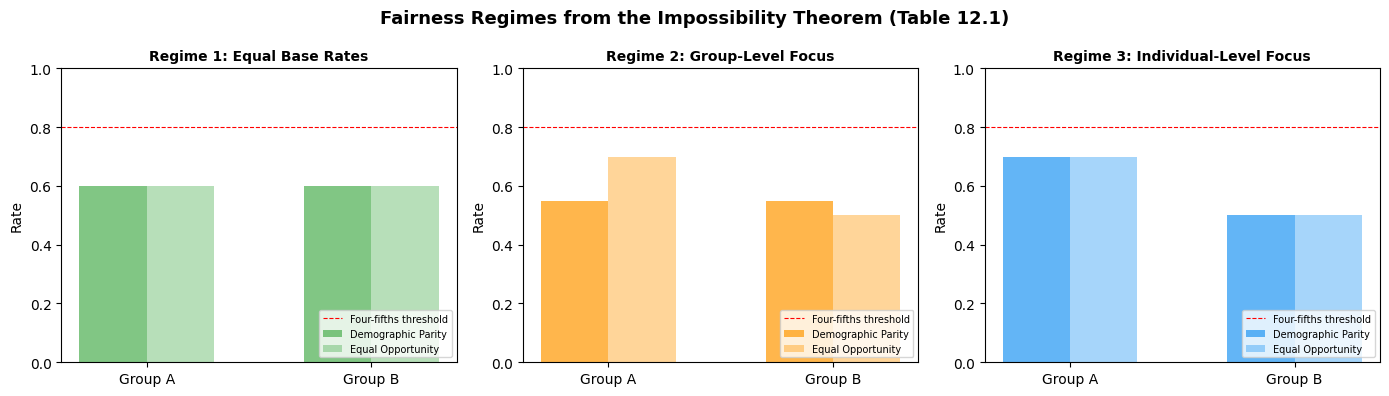

[SUCCESS] 16:41:14 | Notebook01 | Impossibility Theorem regimes visualized.


In [7]:
# Cell 12 — Impossibility Theorem regime visualization
# Ref: Impossibility Theorem (p.337–338), Table 12.1

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Fairness Regimes from the Impossibility Theorem (Table 12.1)", fontsize=13, fontweight="bold")

regimes = [
    ("Regime 1: Equal Base Rates", [0.6, 0.6], [0.6, 0.6], "#4CAF50"),
    ("Regime 2: Group-Level Focus", [0.55, 0.55], [0.7, 0.5], "#FF9800"),
    ("Regime 3: Individual-Level Focus", [0.7, 0.5], [0.7, 0.5], "#2196F3"),
]

groups = ["Group A", "Group B"]
metrics = ["Demographic\nParity", "Equal\nOpportunity"]

for ax, (title, dp_vals, eo_vals, color) in zip(axes, regimes):
    x = np.arange(len(groups))
    width = 0.3
    ax.bar(x - width/2, dp_vals, width, label="Demographic Parity", color=color, alpha=0.7)
    ax.bar(x + width/2, eo_vals, width, label="Equal Opportunity", color=color, alpha=0.4)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylim(0, 1.0)
    ax.axhline(y=0.8, color="red", linestyle="--", linewidth=0.8, label="Four-fifths threshold")
    ax.set_ylabel("Rate")
    ax.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.savefig("impossibility_regimes.png", dpi=100, bbox_inches="tight")
plt.show()
logger.success("Impossibility Theorem regimes visualized.")


## 6. Bias Detection and Mitigation (pp. 339–343)

AI agents inherit biases from their training data. The `BiasDetector` computes three fairness metrics:

- **Demographic Parity** — equal positive outcome rates across groups (p. 342)
- **Equal Opportunity** — equal true-positive rates for qualified candidates (p. 342)
- **Disparate Impact** — ratio of positive outcome rates; the four-fifths rule (0.8) is the legal standard (p. 342)

The `assess_severity()` method converts metric values into escalation signals: `< 0.8` → HIGH, `> 0.1 disparity` → MEDIUM, else LOW.

---

> 📌 **Info Box — The shadow of historical data: Amazon's AI recruiting failure (p. 340)**
>
> In 2018, Reuters reported that Amazon had quietly scrapped an internal AI recruiting tool after discovering it systematically penalized resumes containing terms associated with women. Trained on a decade of hiring data that skewed heavily male, the system learned to downgrade candidates who listed activities like "women's chess club" or attended all-women's colleges. The failure was not a bug in the algorithm — it was a faithful reproduction of the patterns in the data. Had it been an adaptive agent, the bias would have **compounded with each cycle** — exactly the superlinear feedback loop formalized in the Dual-Exposure Model.

---

> 📌 **Info Box — Ethical evaluation as an attack surface (p. 337)**
>
> Three attack vectors are particularly relevant:
> - **Prompt injection against validators** — Defense: validate and sanitize inputs before they reach the ethical layer.
> - **Fairness gaming** — Applicants learn thresholds and exploit them. Defense: rotate anonymization strategies; monitor for proxy signals via mutual information analysis.
> - **Reward hacking in continuous learning** — RLHF systems satisfy constraints while violating their spirit. Defense: a separate constraint model that can veto policy updates.

---

**Mitigation strategies** operate at three pipeline stages (p. 343):
1. **Pre-processing** — Re-weighting, re-sampling, removing proxy variables
2. **In-processing** — Fairness objectives in the loss function
3. **Post-processing** — Group-specific threshold calibration

In [8]:
# Cell 14 — Generate synthetic HR dataset with injected bias
# Ref: Bias Detection and Mitigation (p.339–340), Amazon example (p.341, p.343)

hr_data = generate_hr_dataset(n=200, seed=42)
hr_summary = summarize_hr_dataset(hr_data)

logger.info(f"Dataset: {hr_summary['total_candidates']} candidates")
logger.info(f"Gender distribution: {hr_summary['gender_distribution']}")
logger.info(f"Qualification rates by gender: {hr_summary['qualification_rates_by_gender']}")
logger.info(f"Disparate Impact Ratio (female/male): {hr_summary['disparate_impact_ratio']}")

if hr_summary['four_fifths_compliant']:
    logger.success("Four-fifths rule: COMPLIANT")
else:
    logger.error(f"Four-fifths rule: VIOLATION — DI = {hr_summary['disparate_impact_ratio']:.4f} < 0.80")


[INFO] 16:41:14 | SyntheticData | Generated HR dataset: 200 candidates (seed=42). Bias injected for fairness demonstration.
[INFO] 16:41:14 | Notebook01 | Dataset: 200 candidates
[INFO] 16:41:14 | Notebook01 | Gender distribution: {'female': 81, 'male': 111, 'non_binary': 8}
[INFO] 16:41:14 | Notebook01 | Qualification rates by gender: {'female': 0.4815, 'male': 0.6577, 'non_binary': 0.75}
[INFO] 16:41:14 | Notebook01 | Disparate Impact Ratio (female/male): 0.7321
[ERROR] 16:41:14 | Notebook01 | Four-fifths rule: VIOLATION — DI = 0.7321 < 0.80


In [9]:
# Cell 15 — BiasDetector analysis on the HR dataset
# Ref: BiasDetector (p.341–342)

detector = BiasDetector()

predictions = [r["qualified"] for r in hr_data]
demographics = [r["gender"] for r in hr_data]
ground_truth = [r["raw_score"] >= 0.65 for r in hr_data]

bias_report = detector.analyze(predictions, demographics, ground_truth)

logger.info(f"Severity: {bias_report['severity']}")
logger.info(f"Summary: {bias_report['summary']}")

# Display each metric
for metric_name, metric_data in bias_report["metrics"].items():
    logger.info(f"  {metric_name}: {metric_data}")

logger.info("Recommendations:")
for rec in bias_report["recommendations"]:
    logger.info(f"  → {rec}")


[DEBUG] 16:41:14 | EthicalCore | BiasDetector initialized with 3 metrics.
[INFO] 16:41:14 | Notebook01 | Severity: HIGH
[INFO] 16:41:14 | Notebook01 | Summary: Bias severity: HIGH. Disparate impact ratio: 0.642. Demographic parity difference: 0.2685.
[INFO] 16:41:14 | Notebook01 |   demographic_parity: {'metric': 'demographic_parity', 'group_rates': {'female': 0.4815, 'male': 0.6577, 'non_binary': 0.75}, 'difference': 0.2685}
[INFO] 16:41:14 | Notebook01 |   equal_opportunity: {'metric': 'equal_opportunity', 'group_tpr': {'female': 1.0, 'male': 1.0, 'non_binary': 1.0}, 'difference': 0.0}
[INFO] 16:41:14 | Notebook01 |   disparate_impact: {'metric': 'disparate_impact', 'group_rates': {'female': 0.4815, 'male': 0.6577, 'non_binary': 0.75}, 'ratio': 0.642, 'four_fifths_compliant': False}
[INFO] 16:41:14 | Notebook01 | Recommendations:
[INFO] 16:41:14 | Notebook01 |   → Apply reweighting strategy to restore demographic balance.
[INFO] 16:41:14 | Notebook01 |   → Review anonymization layer 

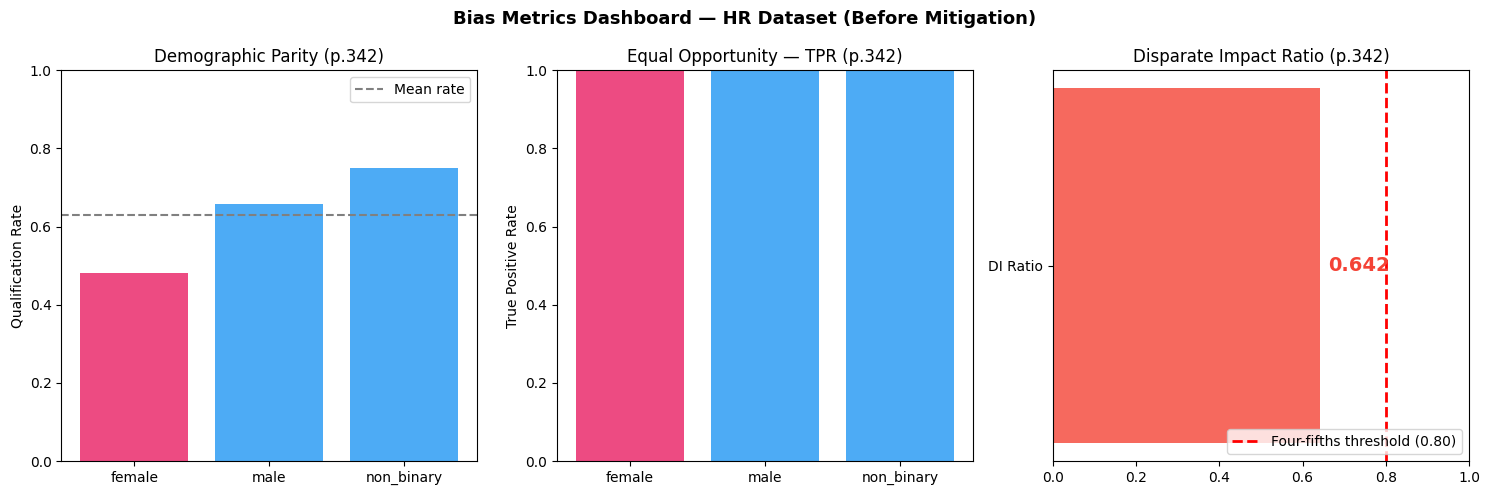

[SUCCESS] 16:41:14 | Notebook01 | Bias metrics dashboard rendered.


In [10]:
# Cell 16 — Bias metrics dashboard visualization
# Ref: Bias Detection (p.341–342)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Bias Metrics Dashboard — HR Dataset (Before Mitigation)", fontsize=13, fontweight="bold")

# 1. Qualification rates by gender (Demographic Parity)
dp_rates = bias_report["metrics"]["demographic_parity"]["group_rates"]
colors_dp = ["#2196F3" if g != "female" else "#E91E63" for g in dp_rates.keys()]
axes[0].bar(dp_rates.keys(), dp_rates.values(), color=colors_dp, alpha=0.8)
axes[0].axhline(y=sum(dp_rates.values()) / len(dp_rates), color="gray", linestyle="--", label="Mean rate")
axes[0].set_title("Demographic Parity (p.342)")
axes[0].set_ylabel("Qualification Rate")
axes[0].set_ylim(0, 1.0)
axes[0].legend()

# 2. Equal Opportunity (TPR by group)
eo_data = bias_report["metrics"]["equal_opportunity"]
if eo_data.get("group_tpr"):
    eo_rates = eo_data["group_tpr"]
    colors_eo = ["#2196F3" if g != "female" else "#E91E63" for g in eo_rates.keys()]
    axes[1].bar(eo_rates.keys(), eo_rates.values(), color=colors_eo, alpha=0.8)
    axes[1].set_title("Equal Opportunity — TPR (p.342)")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_ylim(0, 1.0)
else:
    axes[1].text(0.5, 0.5, "Ground truth\nnot available", ha="center", va="center", fontsize=12)
    axes[1].set_title("Equal Opportunity — TPR (p.342)")

# 3. Disparate Impact ratio gauge
di_data = bias_report["metrics"]["disparate_impact"]
di_ratio = di_data["ratio"]
bar_color = "#4CAF50" if di_ratio >= 0.8 else "#F44336"
axes[2].barh(["DI Ratio"], [di_ratio], color=bar_color, height=0.4, alpha=0.8)
axes[2].axvline(x=0.8, color="red", linestyle="--", linewidth=2, label="Four-fifths threshold (0.80)")
axes[2].set_xlim(0, 1.0)
axes[2].set_title("Disparate Impact Ratio (p.342)")
axes[2].legend(loc="lower right")
axes[2].text(di_ratio + 0.02, 0, f"{di_ratio:.3f}", va="center", fontweight="bold",
             color=bar_color, fontsize=14)

plt.tight_layout()
plt.savefig("bias_dashboard_before.png", dpi=100, bbox_inches="tight")
plt.show()
logger.success("Bias metrics dashboard rendered.")


## 7. Bias Monitoring Pipeline (p.342–343)

Fairness must be monitored continuously — the same way you monitor latency and error rates. The `BiasMonitoringPipeline` turns fairness measurement into a streaming operational control loop:

1. Accumulate decisions in a sliding window
2. Run `BiasDetector` when the window is full
3. Push metrics to the observability platform (Prometheus/Datadog)
4. Fire critical alerts when severity is HIGH


In [11]:
# Cell 18 — BiasMonitoringPipeline streaming simulation
# Ref: BiasMonitoringPipeline (p.342–343)

import random

pipeline = BiasMonitoringPipeline(window_size=100)
rng = random.Random(42)

logger.info("Streaming 200 decisions through the pipeline...")
reports_collected = []

for i in range(200):
    gender = rng.choices(["male", "female"], weights=[0.55, 0.45])[0]
    # Inject bias: females have lower approval rate
    approved = rng.random() > (0.35 if gender == "female" else 0.20)
    result = pipeline.on_decision(approved, gender, ground_truth=approved)
    if result is not None:
        reports_collected.append(result)

logger.info(f"Reports generated: {len(reports_collected)}")

# Show alerts
alerts = pipeline.alert_config.get_alerts()
logger.info(f"Alerts fired: {len(alerts)}")
for alert in alerts:
    logger.error(f"  [{alert['level'].upper()}] {alert['message']}")

# Show gauges
gauges = pipeline.metrics.get_gauges()
for name, val in gauges.items():
    logger.info(f"  Gauge: {name} = {val:.4f}")

logger.success("Bias monitoring pipeline demonstration complete.")


[DEBUG] 16:41:14 | EthicalCore | BiasDetector initialized with 3 metrics.
[DEBUG] 16:41:14 | EthicalCore | BiasMonitoringPipeline initialized (window=100).
[INFO] 16:41:14 | Notebook01 | Streaming 200 decisions through the pipeline...
[DEBUG] 16:41:14 | EthicalCore | Metric emitted: agent.fairness.demographic_parity = 0.1802
[DEBUG] 16:41:14 | EthicalCore | Metric emitted: agent.fairness.disparate_impact = 0.7853
[ERROR] 16:41:14 | EthicalCore | ALERT [CRITICAL]: Disparate impact ratio: 0.785 (below 0.8 threshold)
[DEBUG] 16:41:14 | EthicalCore | Metric emitted: agent.fairness.demographic_parity = 0.2369
[DEBUG] 16:41:14 | EthicalCore | Metric emitted: agent.fairness.disparate_impact = 0.7081
[ERROR] 16:41:14 | EthicalCore | ALERT [CRITICAL]: Disparate impact ratio: 0.708 (below 0.8 threshold)
[INFO] 16:41:14 | Notebook01 | Reports generated: 2
[INFO] 16:41:14 | Notebook01 | Alerts fired: 2
[ERROR] 16:41:14 | Notebook01 |   [CRITICAL] Disparate impact ratio: 0.785 (below 0.8 threshold)

## 8. Case Study: HR Assistant with Fairness Constraints (pp. 343–346)

The `FairHiringAgent` implements a three-layer fairness architecture:

1. **Layer 1 — Anonymization**: strips name, gender, age, nationality, photo, address, and education institution from resumes (p. 345)
2. **Layer 2 — Bias-Aware Evaluation**: monitors decision patterns across demographic groups in real time (p. 344)
3. **Layer 3 — Fairness Enforcement**: intervenes when detected bias exceeds the four-fifths threshold (p. 345)

Three supporting components:
- `ResumeAnalyzer` — skills-matching evaluation returning score in [0, 1] with explanation map
- `BiasDetector` — computes four-fifths (adverse impact) ratio per protected group
- `FairnessEnforcer` — selects from reweighting, threshold adjustment, or calibrated post-processing

---

> 📌 **Info Box — Why anonymization is harder than it appears (p. 346)**
>
> As few as **four quasi-identifying data points** can uniquely re-identify individuals. Writing style and vocabulary choices can serve as fingerprints surviving field-level anonymization. The HR agent should ensure every combination of quasi-identifiers appears in at least *k* resumes (**k-anonymity**). A periodic **proxy audit** using mutual information between remaining features and protected attributes should be integrated into the monitoring pipeline.

---

The `FairHiringAgent` implicitly operates in **Regime 2** of the Impossibility Theorem (p. 346): it prioritizes demographic parity through the four-fifths rule threshold — appropriate for hiring domains where historical exclusion has distorted apparent qualification rates.

In [12]:
# Cell 20 — FairHiringAgent batch evaluation with bias detection
# Ref: FairHiringAgent (p.343–346)

fair_agent = FairHiringAgent(fairness_threshold=0.8)

job_requirements = {
    "required_skills": ["python", "machine_learning", "sql", "data_analysis", "cloud_computing"],
    "min_experience": 3,
    "role": "Senior Data Scientist",
}

logger.info(f"Evaluating {len(hr_data)} candidates for: {job_requirements['role']}")

# Run batch evaluation (includes bias detection + mitigation)
batch_result = fair_agent.evaluate_batch(hr_data, job_requirements)

severity = batch_result["bias_report"]["severity"]
di_before = batch_result["bias_report"]["metrics"]["disparate_impact"]["ratio"]
logger.info(f"Bias severity: {severity}")
logger.info(f"Disparate impact ratio (before mitigation): {di_before:.4f}")


[DEBUG] 16:41:14 | MockLLM | MockLLM initialized with 7 handler methods.
[DEBUG] 16:41:14 | EthicalCore | BiasDetector initialized with 3 metrics.
[DEBUG] 16:41:14 | EthicalCore | FairHiringAgent initialized (threshold=0.8).
[INFO] 16:41:14 | Notebook01 | Evaluating 200 candidates for: Senior Data Scientist
[INFO] 16:41:14 | EthicalCore | Bias detected (severity=HIGH). Applying mitigation...
[SUCCESS] 16:41:14 | EthicalCore | FairnessEnforcer applied 'reweighting': 0.7000 → 0.7500
[SUCCESS] 16:41:14 | EthicalCore | FairnessEnforcer applied 'reweighting': 0.6800 → 0.7300
[SUCCESS] 16:41:14 | EthicalCore | FairnessEnforcer applied 'reweighting': 0.4400 → 0.4900
[SUCCESS] 16:41:14 | EthicalCore | FairnessEnforcer applied 'reweighting': 0.4800 → 0.5300
[SUCCESS] 16:41:14 | EthicalCore | FairnessEnforcer applied 'reweighting': 0.6800 → 0.7300
[SUCCESS] 16:41:14 | EthicalCore | FairnessEnforcer applied 'reweighting': 0.8000 → 0.8500
[SUCCESS] 16:41:14 | EthicalCore | FairnessEnforcer applied

In [13]:
# Cell 21 — Anonymization layer demonstration
# Ref: FairHiringAgent.anonymize() (p.345)

sample_resume = hr_data[0]
logger.info("--- Original Resume (sample) ---")
for key, val in sample_resume.items():
    display_val = str(val)[:60] if isinstance(val, list) else val
    logger.info(f"  {key}: {display_val}")

anonymized = fair_agent.anonymize(sample_resume)
logger.info("--- Anonymized Resume ---")
for key, val in anonymized.items():
    display_val = str(val)[:60] if isinstance(val, list) else val
    logger.info(f"  {key}: {display_val}")

removed = set(sample_resume.keys()) - set(anonymized.keys())
logger.success(f"Fields removed: {sorted(removed)}")


[INFO] 16:41:14 | Notebook01 | --- Original Resume (sample) ---
[INFO] 16:41:14 | Notebook01 |   candidate_id: C-0000
[INFO] 16:41:14 | Notebook01 |   skills: ['aws', 'communication', 'deep_learning', 'machine_learning'
[INFO] 16:41:14 | Notebook01 |   years_experience: 19
[INFO] 16:41:14 | Notebook01 |   education_level: bachelors
[INFO] 16:41:14 | Notebook01 |   education_institution: MIT
[INFO] 16:41:14 | Notebook01 |   gender: female
[INFO] 16:41:14 | Notebook01 |   ethnicity: group_A
[INFO] 16:41:14 | Notebook01 |   raw_score: 0.5589
[INFO] 16:41:14 | Notebook01 |   qualified: False
[INFO] 16:41:14 | Notebook01 | --- Anonymized Resume ---
[INFO] 16:41:14 | Notebook01 |   candidate_id: C-0000
[INFO] 16:41:14 | Notebook01 |   skills: ['aws', 'communication', 'deep_learning', 'machine_learning'
[INFO] 16:41:14 | Notebook01 |   years_experience: 19
[INFO] 16:41:14 | Notebook01 |   education_level: bachelors
[INFO] 16:41:14 | Notebook01 |   ethnicity: group_A
[INFO] 16:41:14 | Notebook

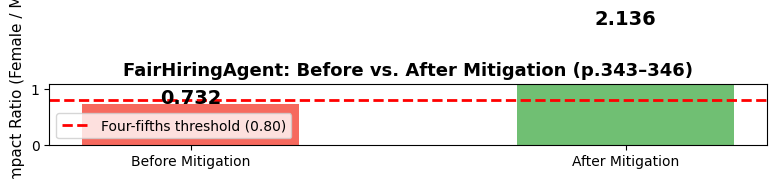

[SUCCESS] 16:41:14 | Notebook01 | Mitigation effective: DI improved from 0.732 to 2.136 (≥ 0.80)
[INFO] 16:41:14 | Notebook01 | Audit trail: 1 entries recorded for compliance review


In [14]:
# Cell 22 — Before/after fairness comparison chart
# Ref: FairHiringAgent case study (p.343–346)

# BEFORE mitigation: raw scores
before_preds = [r["raw_score"] >= 0.65 for r in hr_data]
before_genders = [r["gender"] for r in hr_data]

# AFTER mitigation: mitigated scores from batch_result
after_evals = batch_result["evaluations"]
after_preds = [e["score"] >= 0.65 for e in after_evals]

# Compute DI ratios
def compute_di(preds, genders):
    groups = {}
    for p, g in zip(preds, genders):
        groups.setdefault(g, []).append(p)
    rates = {g: sum(ps) / len(ps) for g, ps in groups.items()}
    f_rate = rates.get("female", 0)
    m_rate = rates.get("male", 1)
    return round(f_rate / m_rate, 4) if m_rate > 0 else 0

di_before = compute_di(before_preds, before_genders)
di_after = compute_di(after_preds, before_genders)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(["Before Mitigation", "After Mitigation"], [di_before, di_after],
              color=["#F44336", "#4CAF50"], alpha=0.8, width=0.5)
ax.axhline(y=0.8, color="red", linestyle="--", linewidth=2, label="Four-fifths threshold (0.80)")
ax.set_ylabel("Disparate Impact Ratio (Female / Male)", fontsize=11)
ax.set_title("FairHiringAgent: Before vs. After Mitigation (p.343–346)", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)

for bar, val in zip(bars, [di_before, di_after]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", fontweight="bold", fontsize=14)

plt.tight_layout()
plt.savefig("fairness_before_after.png", dpi=100, bbox_inches="tight")
plt.show()

if di_after >= 0.8:
    logger.success(f"Mitigation effective: DI improved from {di_before:.3f} to {di_after:.3f} (≥ 0.80)")
else:
    logger.info(f"DI after mitigation: {di_after:.3f} — further tuning may be needed")

# Audit trail
audit = fair_agent.audit_logger.get_log()
logger.info(f"Audit trail: {len(audit)} entries recorded for compliance review")


## Summary & Exercises

### Key Takeaways

1. **Deontic logic** (p.332–333) provides a formal language for encoding obligation, permission, and prohibition — making ethical constraints machine-executable.
2. The **Ethical Consistency Theorem** (p.333) gives a computationally verifiable criterion: an action is permitted only if it is logically consistent with the entire rule set.
3. The **EthicalReasoningAgent** (p.334–335) embeds an ethical checkpoint between reasoning and action, using modular validators aligned with IEEE Ethically Aligned Design.
4. The **Impossibility Theorem** (p.337–338) proves that perfect fairness across all metrics is mathematically impossible when base rates differ — the choice of regime is a normative decision.
5. The **FairHiringAgent** (p.343–346) demonstrates a three-layer fairness architecture that detects bias (DI ≈ 0.73) and mitigates it through reweighting.

### Exercises

1. **Add a new principle checker**: Create a `PrivacyChecker` that detects data retention violations and integrate it into `EthicalReasoningAgent`.
2. **Tune the fairness threshold**: Change the `fairness_threshold` to 0.9 and observe how the mitigation strategy changes.
3. **Implement Regime 3**: Modify the `FairHiringAgent` to prioritize equal opportunity instead of demographic parity. How does this change the disparate impact ratio?
4. **Proxy audit** (p.346): Compute mutual information between remaining features (skills, experience) and gender after anonymization. Are there hidden proxy signals?

---
*Author: Imran Ahmad — Packt Publishing, 2026*
